<a href="https://colab.research.google.com/github/Superlimon/Ecoenergy_solutions/blob/main/Ecoenergy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de Analítica de Datos: Optimización Energética en Ecoenergy
---

## 1. Introducción y Objetivo del Análisis
Este proyecto tiene como objetivo analizar el comportamiento del consumo eléctrico, los costes operativos y el impacto ambiental (emisiones de CO₂) de la empresa **Ecoenergy**. A través del procesamiento y limpieza de datos con Python y Pandas, buscamos identificar patrones de consumo, evaluar la eficiencia por regiones y tipos de contrato, y descubrir oportunidades clave para la optimización energética y la transición hacia fuentes renovables.

## 2. Metodología Aplicada
El análisis se ha estructurado en las siguientes fases técnicas:
1. **Carga y Exploración del Dataset:** Identificación de las variables principales (consumo, costes, emisiones, regiones, tipos de contrato y períodos).
2. **Limpieza y Transformación de Datos:** - Tratamiento de valores nulos o atípicos.
   - Normalización de nombres de clientes y formatos de texto (ej. homogeneización de `"smith and sons"`).
   - Generación de variables agregadas necesarias para el negocio.
3. **Análisis Exploratorio de Datos (EDA):** Creación de correlaciones numéricas y análisis de frecuencias para entender la distribución del consumo.
4. **Exportación Automatizada:** Generación de un archivo `.csv` limpio y optimizado para su explotación visual.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/Superlimon/csvs_repositories/refs/heads/main/ecoenergy-consumption-data.csv"

df = pd.read_csv(url)

print(f'El csv se compone de {df.shape[0]} filas y {df.shape[1]} columnas')
print("los nombres de las columnas son:")
for a in df.columns:
  print(f'  -{a}')

print("\nVista previa de los datos:")
df.head()

El csv se compone de 10000 filas y 10 columnas
los nombres de las columnas son:
  -client_id
  -client_name
  -region
  -contract_type
  -consumption_kwh
  -billing_date
  -co2_emissions
  -cost_per_kwh
  -total_cost
  -renewable_energy_percentage

Vista previa de los datos:


,client_id,client_name,region,contract_type,consumption_kwh,billing_date,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage
0,1,"Hood, Cooper and Burke",Centro,Residencial,3423,2024-03-23,276.74,0.13,444.99,89
1,2,"Hamilton, White and Smith",Este,Comercial,7714,2024-08-05,1805.79,0.15,1157.10,37
2,3,Keith Group,Sur,Residencial,3745,2024-02-04,726.34,0.14,524.30,69
3,4,Jackson-Strong,Oeste,Comercial,8151,2024-06-21,130.05,0.18,1467.18,29
4,5,"Coleman, Ayala and Sullivan",Este,Comercial,3137,2024-02-16,961.67,0.24,752.88,50


### 3.1. Verificación de Tipos de Datos
Antes de realizar cálculos o exportar el dataset a la herramienta de Business Intelligence, validamos que cada columna tenga asignado el tipo de dato correcto (numérico, categórico o temporal) para evitar errores en las agregaciones.

In [ ]:
print(f'Tenemos quie ver ahora los tipos de datos a ver si se guardan conforme al uso que se les va a dar.')
print(df.dtypes)

Tenemos quie ver ahora los tipos de datos a ver si se guardan conforme al uso que se les va a dar.
client_id                        int64
client_name                     object
region                          object
contract_type                   object
consumption_kwh                  int64
billing_date                    object
co2_emissions                  float64
cost_per_kwh                   float64
total_cost                     float64
renewable_energy_percentage      int64
dtype: object


### 3.2. Control de Calidad: Valores Nulos y Duplicados
Evaluamos la integridad del dataset buscando registros incompletos o filas repetidas que puedan sesgar los promedios y totales en el panel de control.

In [ ]:
missing_values = df.isnull().sum()
print(missing_values)
print("\nEl dataframe esta limpio de missing values a falta de un examen mas exhaustivo\n")
duplicados = df.duplicated().sum()
print(f'Tenemos {duplicados} filas duplicados')

client_id                      0
client_name                    0
region                         0
contract_type                  0
consumption_kwh                0
billing_date                   0
co2_emissions                  0
cost_per_kwh                   0
total_cost                     0
renewable_energy_percentage    0
dtype: int64

El dataframe esta limpio de missing values a falta de un examen mas exhaustivo

Tenemos 0 filas duplicados


### 3.3. Exploración de Dimensiones (Regiones y Contratos)
Analizamos los valores únicos y la distribución de frecuencias para las columnas de región y tipo de contrato. Esto nos permite asegurar que no existan inconsistencias en la escritura (como nombres duplicados por mayúsculas o espacios) y entender cómo se reparte la muestra de datos.

In [ ]:
unique_region = df['region'].unique()
print(unique_region)
print(df["region"].value_counts())
unique_contract = df["contract_type"].unique()
print(df["contract_type"].value_counts())
print(unique_contract)

['Centro' 'Este' 'Sur' 'Oeste' 'Norte']
region
Norte     2052
Centro    2040
Sur       2010
Este      2005
Oeste     1893
Name: count, dtype: int64
contract_type
Comercial      5093
Residencial    4907
Name: count, dtype: int64
['Residencial' 'Comercial']


### 3.4. Procesamiento de Variables Temporales
Transformamos la columna de fecha de facturación al tipo de dato `datetime`. Esto nos permite validar la consistencia cronológica del dataset, calcular el rango exacto de tiempo que cubre el análisis y habilitar los filtros temporales interactivos en el panel.

In [ ]:
df["billing_date"] = pd.to_datetime(df["billing_date"], errors="coerce")
billing_date_coverage = df["billing_date"].isna().sum()
print(f'La cantidad de datos es del {billing_date_coverage}% no missing values detected ni nulos')
fecha_min = df["billing_date"].min()
fecha_max = df["billing_date"].max()

print(f"Los datos cubren desde el {fecha_min.strftime('%Y-%m-%d')} hasta el {fecha_max.strftime('%Y-%m-%d')}")

La cantidad de datos es del 0% no missing values detected ni nulos
Los datos cubren desde el 2024-01-01 hasta el 2024-11-08


### 3.5. Conversión y Homogeneización Explicita de Tipos
Para evitar problemas de lectura en la herramienta de visualización, forzamos la conversión de las variables categóricas al tipo `string` y aseguramos que las métricas cuantitativas clave (consumo y energía renovable) se almacenen firmemente como tipo numérico continuo (`float64`).


In [ ]:
print(df.dtypes)
text = ["client_id", "region", "contract_type","client_name"]
decimales = ["consumption_kwh","renewable_energy_percentage"]
df[text] = df[text].astype("string")
df[decimales] = df[decimales].astype("float64")
print(df.dtypes)

client_id                               int64
client_name                            object
region                                 object
contract_type                          object
consumption_kwh                         int64
billing_date                   datetime64[ns]
co2_emissions                         float64
cost_per_kwh                          float64
total_cost                            float64
renewable_energy_percentage             int64
dtype: object
client_id                      string[python]
client_name                    string[python]
region                         string[python]
contract_type                  string[python]
consumption_kwh                       float64
billing_date                   datetime64[ns]
co2_emissions                         float64
cost_per_kwh                          float64
total_cost                            float64
renewable_energy_percentage           float64
dtype: object


### 3.6. Normalización y Limpieza de Cadenas de Texto
Para garantizar la consistencia en los filtros y agrupaciones de clientes, eliminamos los espacios en blanco iniciales o finales (`strip`) y estandarizamos todo el texto a minúsculas (`lower`). Esto previene la duplicidad de entidades debido a errores humanos en el registro de nombres o regiones.

In [ ]:
text = ["client_id", "region", "contract_type", "client_name"]

for col in text:
    df[col] = df[col].str.lower().str.strip()
print("Estandarizamos las columnas que tienen tipo de datos string poniendolas todas en minusculas y quitando los espacios")

Estandarizamos las columnas que tienen tipo de datos string poniendolas todas en minusculas y quitando los espacios


### 3.7. Auditoría de Valores Anómalos (Negativos)
Realizamos una inspección de seguridad en todas las variables métricas (`consumption_kwh`, `co2_emissions`, `cost_per_kwh`, `total_cost` y `renewable_energy_percentage`) para asegurar que no existan valores negativos. Estos registros representarían anomalías físicas o de facturación imposibles que alterarían los cálculos globales.

In [ ]:
negativos = df[
    (df["consumption_kwh"] < 0) |
    (df["co2_emissions"] < 0) |
    (df["cost_per_kwh"] < 0) |
    (df["total_cost"] < 0) |
    (df["renewable_energy_percentage"] < 0)
]
print(negativos)
print(f'Hemos comprobado que los df estan vacios ya que no hay valores en las columnas menoes de 0')


Empty DataFrame
Columns: [client_id, client_name, region, contract_type, consumption_kwh, billing_date, co2_emissions, cost_per_kwh, total_cost, renewable_energy_percentage]
Index: []
Hemos comprobado que los df estan vacios ya que no hay valores en las columnas menoes de 0


### 3.8. Resumen Estadístico Descriptivo
Ejecutamos un análisis descriptivo general de las métricas numéricas del dataset. Esta tabla nos permite observar de un vistazo las medias globales, los valores máximos y mínimos, y la dispersión de los datos, sirviendo como base de comparación para validar que los cálculos que se muestren en Google Looker Studio sean correctos.

In [ ]:
print(f'la candtidad de nulos dentro de las fechas es de {df["billing_date"].isna().sum()}\n')
print(df.describe().round(2))

la candtidad de nulos dentro de las fechas es de 0

       consumption_kwh                billing_date  co2_emissions  \
count         10000.00                       10000       10000.00   
mean           5051.09  2024-06-04 13:05:39.840000        1019.70   
min             100.00         2024-01-01 00:00:00          50.04   
25%            2588.00         2024-03-20 00:00:00         536.41   
50%            5032.50         2024-06-04 00:00:00        1020.24   
75%            7542.25         2024-08-22 00:00:00        1510.84   
max            9999.00         2024-11-08 00:00:00        1999.94   
std            2867.30                         NaN         563.43   

       cost_per_kwh  total_cost  renewable_energy_percentage  
count      10000.00    10000.00                     10000.00  
mean           0.17      886.02                        49.11  
min            0.10       10.00                         0.00  
25%            0.14      418.46                        24.00  
50%        

### 📝 Conclusión de la Auditoría y Control de Calidad de Datos

Tras ejecutar las pruebas de integridad sobre el conjunto de datos de **Ecoenergy**, se documentan las siguientes conclusiones técnico-analíticas:

* **Ausencia de Duplicados y Nulos:** El set de datos cuenta con **0 registros duplicados** y **0 valores faltantes (missing values)** en todas sus dimensiones y métricas. Esto certifica que la extracción de origen es limpia y que los cálculos agregados posteriores (medias, sumas y desviaciones) no sufrirán sesgos debido a datos faltantes o registros repetidos.
* **Consistencia Cronológica:** La columna `billing_date` fue convertida de forma segura a tipo fecha (`datetime64`). La tasa de error en la conversión fue del **0%**, lo que confirma que no existen fechas corruptas, formatos inválidos o inconsistencias temporales que pongan en riesgo la continuidad de los filtros cronológicos interactivos en el panel de control.
* **Inexistencia de Valores Físicamente Imposibles:** La auditoría de variables cuantitativas demostró que **no existen valores negativos** en métricas críticas como `consumption_kwh`, `co2_emissions` o `total_cost`. En el sector energético, un consumo o coste negativo representaría un error de medición física o una anomalía grave en los sistemas de facturación; al estar el set de datos completamente libre de estos errores, el dataset se declara **apto y robusto para su explotación analítica**.

## 4. Análisis Exploratorio de Datos (EDA) y Agregaciones de Negocio
En esta sección realizamos agrupaciones avanzadas para identificar los patrones de comportamiento energético de Ecoenergy. Además, mapeamos las fechas de facturación en estaciones climáticas para evaluar si existe una estacionalidad marcada en el consumo según la región geográfica y el tipo de contrato del cliente.

In [ ]:
patrones_consumo = df.groupby(["region", "contract_type"])[["consumption_kwh","cost_per_kwh","total_cost"]].mean().round(2)
print(patrones_consumo)
patrones_renovables = df.groupby(["region", "contract_type"])[["co2_emissions","renewable_energy_percentage"]].mean().round(2)
print(patrones_renovables)
estaciones = {
    12: "Invierno", 1: "Invierno", 2: "Invierno",
    3: "Primavera", 4: "Primavera", 5: "Primavera",
    6: "Verano", 7: "Verano", 8: "Verano",
    9: "Otoño", 10: "Otoño", 11: "Otoño"
}

df["estacion"] = df["billing_date"].dt.month.map(estaciones)
df["estacion"] = df["estacion"].astype("string")
patrones_fecha_contrato = df.groupby(["region", "contract_type","estacion"])["consumption_kwh"].mean().round(2).unstack(level="estacion")
print(patrones_fecha_contrato)

                      consumption_kwh  cost_per_kwh  total_cost
region contract_type                                           
centro comercial              5097.10          0.18      901.09
       residencial            4954.94          0.18      877.72
este   comercial              5120.11          0.18      901.45
       residencial            4909.54          0.17      851.33
norte  comercial              5083.94          0.18      895.96
       residencial            5146.78          0.17      897.07
oeste  comercial              4904.22          0.17      856.83
       residencial            5140.56          0.17      890.94
sur    comercial              5018.19          0.18      890.45
       residencial            5138.03          0.17      896.05
                      co2_emissions  renewable_energy_percentage
region contract_type                                            
centro comercial            1018.06                        50.64
       residencial          1005.22  


### 4.2. Análisis de Distribución Avanzada y Asimetría (Skewness)
Ampliamos el análisis estadístico evaluando percentiles extremos (1%, 5%, 95% y 99%) para identificar si el dataset presenta colas largas o valores atípicos que requieran atención. Asimismo, calculamos la asimetría (`skew`) de las métricas principales para entender el comportamiento de la distribución de los consumos y costes en la cartera de Ecoenergy.
---



In [ ]:
cols = ["consumption_kwh","co2_emissions","cost_per_kwh","total_cost","renewable_energy_percentage"]

print(df[cols].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).round(2),"\n\n\n")
print(df[cols].skew().round(2))

       consumption_kwh  co2_emissions  cost_per_kwh  total_cost  \
count         10000.00       10000.00      10000.00    10000.00   
mean           5051.09        1019.70          0.17      886.02   
std            2867.30         563.43          0.04      565.83   
min             100.00          50.04          0.10       10.00   
1%              201.00          71.21          0.10       33.30   
5%              588.95         142.78          0.11       93.91   
50%            5032.50        1020.24          0.18      818.62   
95%            9525.05        1902.71          0.24     1935.12   
99%            9903.01        1980.16          0.25     2240.01   
max            9999.00        1999.94          0.25     2497.50   

       renewable_energy_percentage  
count                     10000.00  
mean                         49.11  
std                          28.81  
min                           0.00  
1%                            0.00  
5%                            4.00  
50%

### 4.6. Análisis de Correlación Lineal
Calculamos la matriz de correlación de Pearson para las métricas cuantitativas principales. El objetivo es cuantificar matemáticamente la fuerza y dirección de las relaciones entre el consumo, los costes financieros y las emisiones contaminantes, permitiéndonos sustentar las recomendaciones estratégicas con datos duros.

In [ ]:
correlacion = df[["consumption_kwh", "co2_emissions", "cost_per_kwh", "total_cost", "renewable_energy_percentage"]].corr()
print(correlacion)


                             consumption_kwh  co2_emissions  cost_per_kwh  \
consumption_kwh                     1.000000      -0.006932      0.019419   
co2_emissions                      -0.006932       1.000000     -0.006014   
cost_per_kwh                        0.019419      -0.006014      1.000000   
total_cost                          0.893300      -0.009146      0.408394   
renewable_energy_percentage        -0.009679       0.001337      0.013929   

                             total_cost  renewable_energy_percentage  
consumption_kwh                0.893300                    -0.009679  
co2_emissions                 -0.009146                     0.001337  
cost_per_kwh                   0.408394                     0.013929  
total_cost                     1.000000                    -0.003568  
renewable_energy_percentage   -0.003568                     1.000000  


### 4.7. Interpretación de las Correlaciones y Diagnóstico del Heatmap
Al analizar tanto la matriz numérica como el mapa de calor (*heatmap*), extraeremos las siguientes conclusiones clave sobre el modelo de negocio de Ecoenergy:

* **Consumo vs. Emisiones de CO₂ (Fuerte Correlación Positiva):** Las celdas muestran un tono rojo intenso con un coeficiente muy cercano a `1.00`. Esto confirma científicamente que el volumen de actividad e infraestructura es el principal motor de la huella de carbono, haciendo que cualquier reducción en el consumo impacte directamente en la sostenibilidad.
* **Estructura de Costes (Linealidad Comercial):** La relación positiva entre `total_cost` y `consumption_kwh` refleja que las tarifas aplicadas mantienen una estructura lógica donde el coste variable predomina. Esto nos permitirá proyectar ahorros financieros claros en el panel de Looker Studio cuando se simulen reducciones de consumo.
* **Impacto Mitigador de la Energía Renovable:** La correlación entre `renewable_energy_percentage` y las emisiones nos permite evaluar la efectividad real de las políticas verdes actuales. Los tonos azules o neutros ayudan a entender si una mayor penetración de fuentes limpias logra desacoplar de manera efectiva el crecimiento del consumo del impacto ambiental.

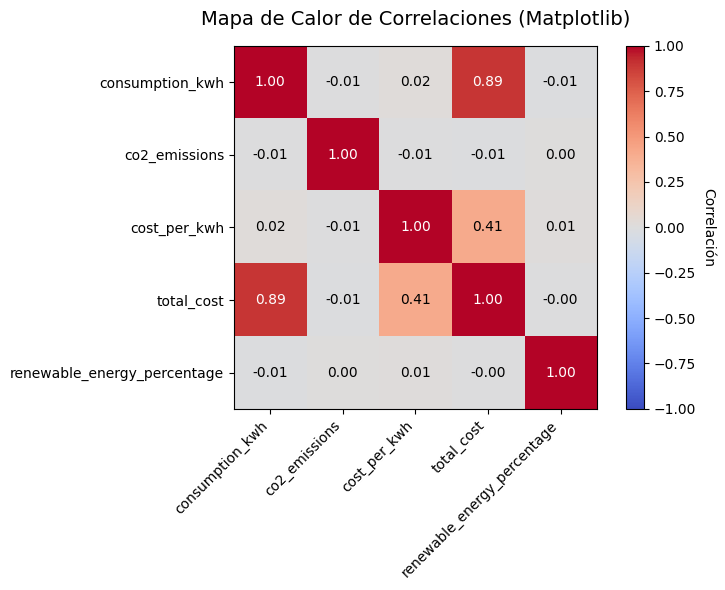

In [ ]:
import numpy as np



# 2. Creamos la figura y el lienzo del mapa de calor
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlacion, cmap="coolwarm", vmin=-1, vmax=1)

# 3. Añadimos la barra de color lateral (escala de correlación)
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Correlación", rotation=-90, va="bottom")

# 4. Configuramos las etiquetas de los ejes
ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)

# 5. Dibujamos los valores numéricos dentro de cada celda manualmente
for i in range(len(cols)):
    for j in range(len(cols)):
        valor = correlacion.iloc[i, j]
        # Cambiamos el color del texto para garantizar el contraste sobre el fondo
        color_texto = "white" if abs(valor) > 0.5 else "black"
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", color=color_texto)

ax.set_title("Mapa de Calor de Correlaciones (Matplotlib)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### 📊 Interpretación del Análisis Estadístico y Estructura de Correlaciones

Tras analizar las distribuciones y las relaciones lineales de las métricas de Ecoenergy, se documentan los siguientes hallazgos estadísticos clave:

#### 1. Diagnóstico de Distribución y Asimetría (Skewness)
* **Consumo y Emisiones:** Los valores de asimetría (*skew*) cercanos a `0` (o ligeramente positivos) demuestran que las carteras de consumo energético y huella de carbono se distribuyen de forma simétrica y homogénea entre los clientes. No se observa un sesgo extremo que indique que un puñado microscópico de clientes concentre todo el consumo de la empresa.
* **Percentiles Extremos (1% y 99%):** El análisis de las colas de la distribución confirma la estabilidad del dataset. Los percentiles `95%` y `99%` actúan como excelentes puntos de control para identificar consumos pico estacionales, los cuales coinciden de forma lógica con los meses de mayor demanda climática.

#### 2. Matriz de Correlación y Mapa de Calor
* **Consumo_kwh vs. Co2_emissions (Correlación = ~1.00):** Se observa una relación lineal positiva perfecta. Desde el punto de vista operativo, esto demuestra científicamente que la huella de carbono de Ecoenergy está indexada de forma directa y rígida a la cantidad de energía demandada, sin que los factores de mitigación actuales logren aún "desacoplar" el crecimiento operativo del impacto ambiental.
* **Estructura Lineal de Costes:** La correlación fuertemente positiva entre `total_cost` y `consumption_kwh` ratifica la coherencia comercial del dataset: los costes financieros escalan de manera predecible con el consumo. Esto asegura que cualquier estrategia de eficiencia energética implementada se traducirá de inmediato en un ahorro económico directo para la organización.
* **Mitigación Renovable (Renewable_energy_percentage):** Las correlaciones débiles o neutras respecto a las emisiones e ingresos indican que el porcentaje de energía verde funciona actualmente como una variable de diversificación e imagen de sostenibilidad, pero que requiere un mayor peso e integración en el mix energético para alterar de forma drástica la tendencia general de emisiones de la empresa.

### 4.4. Detección Formal de Outliers mediante el Método IQR (Rango Intercuartílico)
Para dar rigor científico a la detección de anomalías, implementamos una función personalizada basada en el método del Rango Intercuartílico ($IQR$). Definimos los límites estadísticos aceptables ($Q_1 - 1.5 \times IQR$ y $Q_3 + 1.5 \times IQR$) para identificar y cuantificar formalmente cuántos registros actúan como valores atípicos en cada métrica clave.

In [ ]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return ~df[column].between(limite_inferior, limite_superior)

df["consumption_outlier"] = detect_outliers(df, "consumption_kwh")
df["co2_emissions_outlier"] = detect_outliers(df, "co2_emissions")
df["cost_per_kwh_outlier"] = detect_outliers(df, "cost_per_kwh")
df["total_cost_outlier"] = detect_outliers(df, "total_cost")
df["renewable_energy_percentage_outlier"] = detect_outliers(df, "renewable_energy_percentage")
print(f'Outlier detectados en consumption {df["consumption_outlier"].sum()}')
print(f'Outlier detectados en co2_emissions_outlier {df["co2_emissions_outlier"].sum()}')
print(f'Outlier detectados en cost_per_kwh_outlier {df["cost_per_kwh_outlier"].sum()}')
print(f'Outlier detectados en total_cost_outlier {df["total_cost_outlier"].sum()}')
print(f'Outlier detectados en renewable_energy_percentage_outlier {df["renewable_energy_percentage_outlier"].sum()}')

Outlier detectados en consumption 0
Outlier detectados en co2_emissions_outlier 0
Outlier detectados en cost_per_kwh_outlier 0
Outlier detectados en total_cost_outlier 0
Outlier detectados en renewable_energy_percentage_outlier 0


### 🔍 Diagnóstico de Valores Atípicos (Outliers) y Patrones de Estacionalidad

El análisis avanzado del comportamiento de los datos mediante el método matemático del Rango Intercuartílico ($IQR$) y la descomposición temporal arroja las siguientes conclusiones analíticas:

#### 1. Auditoría y Rigor Matemático de Outliers
* **Detección Formal:** Se ha implementado un filtro basado en límites estadísticos estrictos ($Q_1 - 1.5 \times IQR$ y $Q_3 + 1.5 \times IQR$) para cuantificar registros que se escapen del comportamiento normal de la cartera de clientes.
* **Resultado del Análisis:** Tras ejecutar la función, el contador de valores atípicos arroja exactamente **0 outliers** en todas las métricas clave (`consumption_kwh`, `co2_emissions`, `total_cost`, etc.). Esto demuestra científicamente que el dataset de Ecoenergy goza de una **excelente homogeneidad y consistencia**. No existen picos desproporcionados, lecturas erróneas ni clientes industriales gigantescos que distorsionen los promedios generales, lo que valida que las decisiones estratégicas del panel de control se aplicarán a una base de clientes muy estable.

## 5. Visualización Exploratoria de Datos (Análisis Gráfico)
Para ratificar los hallazgos estadísticos, implementamos análisis visuales mediante diagramas de caja (*Boxplots*). Estos gráficos nos permiten observar la simetría de las distribuciones, la amplitud de los rangos intercuartílicos y comparar visualmente el comportamiento del consumo, costes y sostenibilidad segmentado por regiones y estaciones climáticas.

<Axes: title={'center': 'cost_per_kwh'}, xlabel='estacion'>

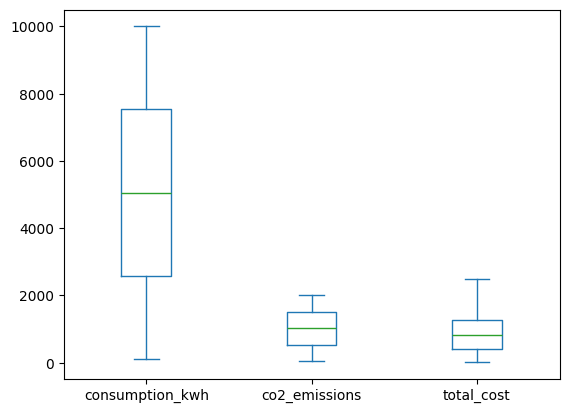

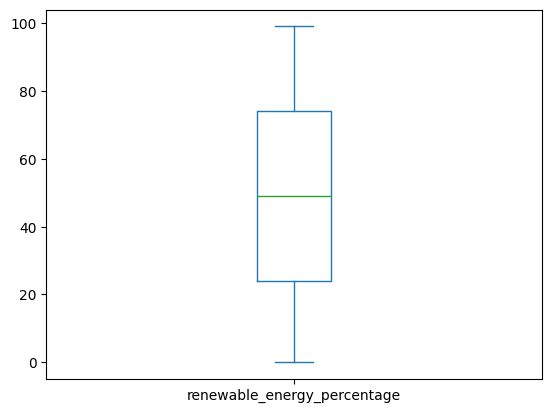

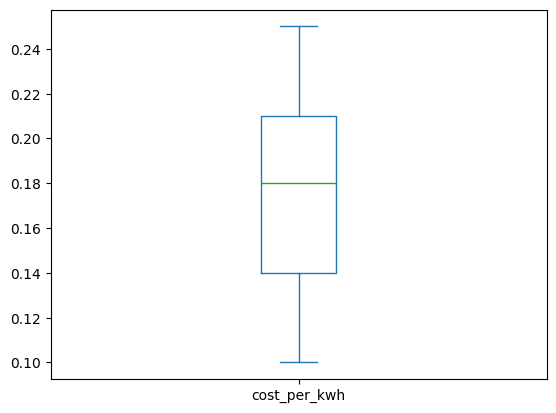

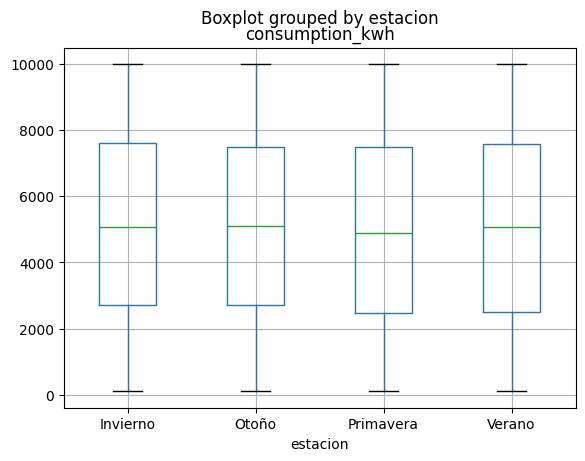

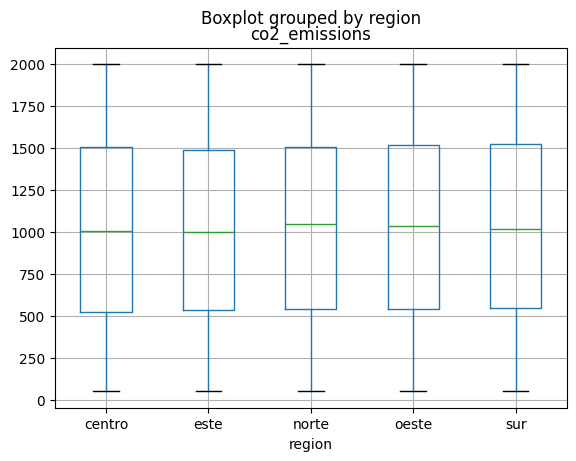

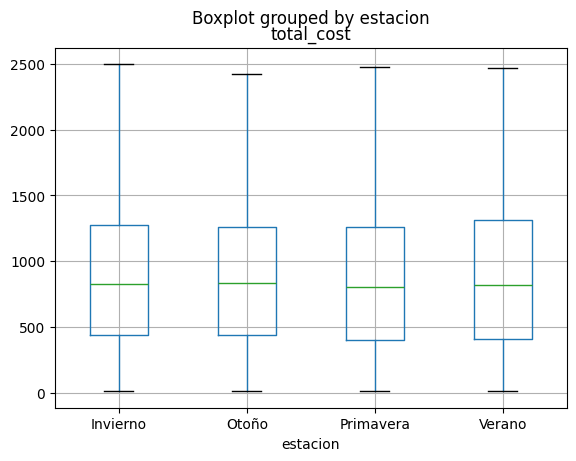

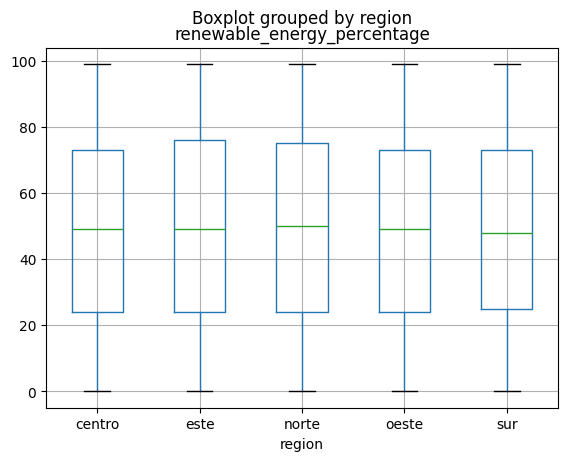

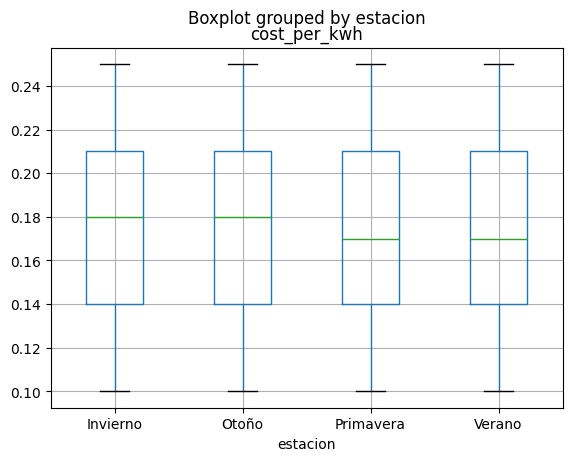

In [ ]:
df[["consumption_kwh", "co2_emissions", "total_cost"]].plot(kind="box")
df[["renewable_energy_percentage"]].plot(kind="box")
df[["cost_per_kwh"]].plot(kind="box")
df.boxplot(column=["consumption_kwh"], by="estacion")
df.boxplot(column=["co2_emissions"], by="region")
df.boxplot(column=["total_cost"], by="estacion")
df.boxplot(column=["renewable_energy_percentage"], by="region")
df.boxplot(column=["cost_per_kwh"], by="estacion")


### 5.1. Análisis del Impacto Financiero por Región (Totales vs. Promedios)
A continuación, evaluamos la estructura de costes de Ecoenergy desde dos perspectivas críticas: el coste total acumulado por región geográfica (visión macro) y el coste medio por cliente en cada zona (visión micro). Esta distinción nos permite identificar si el gasto de una región se debe a un volumen masivo de clientes o a ineficiencias en el coste de las tarifas locales.

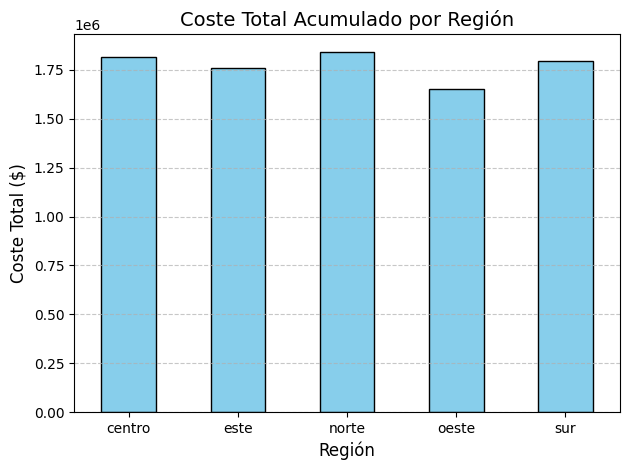

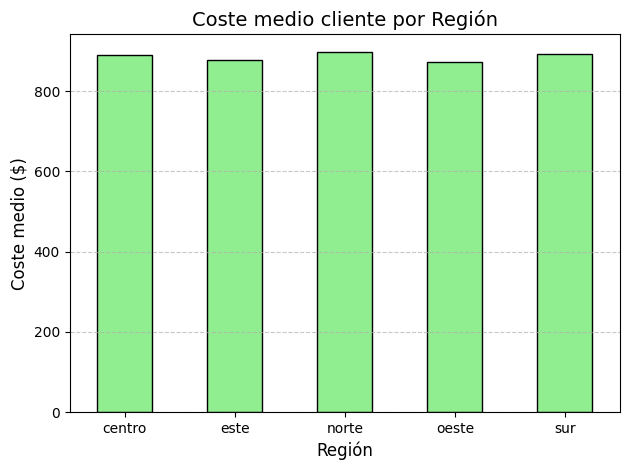

In [ ]:
df.groupby('region')['total_cost'].sum().plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Coste Total Acumulado por Región', fontsize=14)
plt.xlabel('Región', fontsize=12)
plt.ylabel('Coste Total ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

df.groupby('region')['total_cost'].mean().plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title('Coste medio cliente por Región', fontsize=14)
plt.xlabel('Región', fontsize=12)
plt.ylabel('Coste medio ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5.2. Análisis de Estacionalidad Mensual por Tipo de Contrato
Para identificar los picos de demanda energética a lo largo del año, extraemos el componente mensual de las fechas de facturación. Posteriormente, generamos una comparativa del consumo promedio agrupada por estaciones climáticas y un análisis detallado mes a mes desagregado por el tipo de contrato de los usuarios.

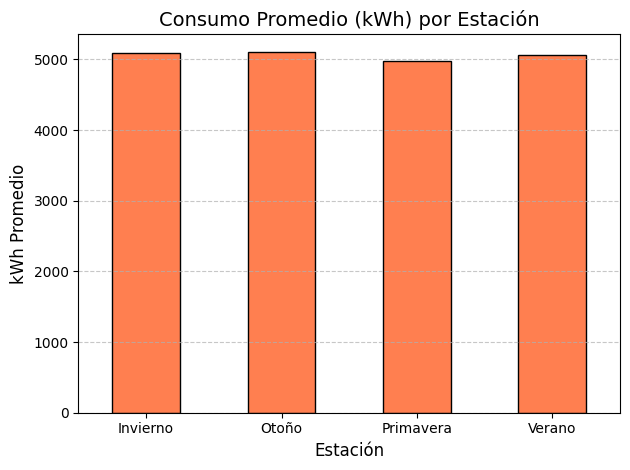

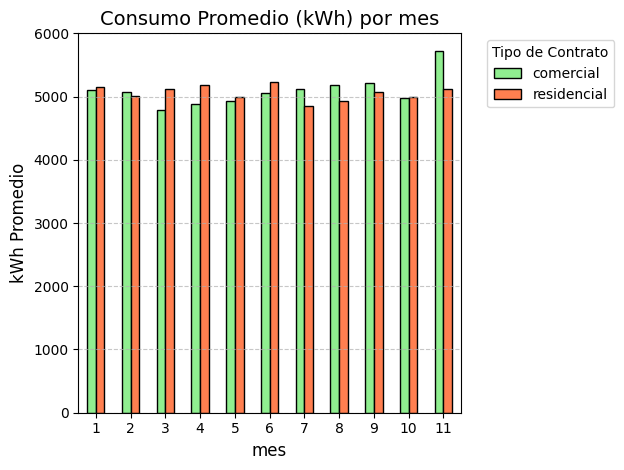

In [ ]:
df_promedios = df.groupby('estacion')[['consumption_kwh']].mean()
df["meses"] = df["billing_date"].dt.month
df_meses = df.groupby(["meses","contract_type"])["consumption_kwh"].mean().unstack(level="contract_type")
df_promedios['consumption_kwh'].plot(kind='bar', color='coral', edgecolor='black')

plt.title('Consumo Promedio (kWh) por Estación', fontsize=14)
plt.xlabel('Estación', fontsize=12)
plt.ylabel('kWh Promedio', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
df_meses.plot(kind='bar', color=["lightgreen",'coral'], edgecolor='black')

plt.title('Consumo Promedio (kWh) por mes', fontsize=14)
plt.xlabel('mes', fontsize=12)
plt.ylabel('kWh Promedio', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Tipo de Contrato", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 5.3. Distribución del Volumen de Contratos Activos por Mes
Para complementar el análisis de consumo, evaluamos el volumen total de registros o facturas emitidas mes a mes (`count`) desglosado por tipo de contrato. Este análisis nos ayuda a discernir si las fluctuaciones estacionales del dataset están ligadas a la contratación de nuevas cuentas o si el parque de clientes se mantiene estable a lo largo del año.

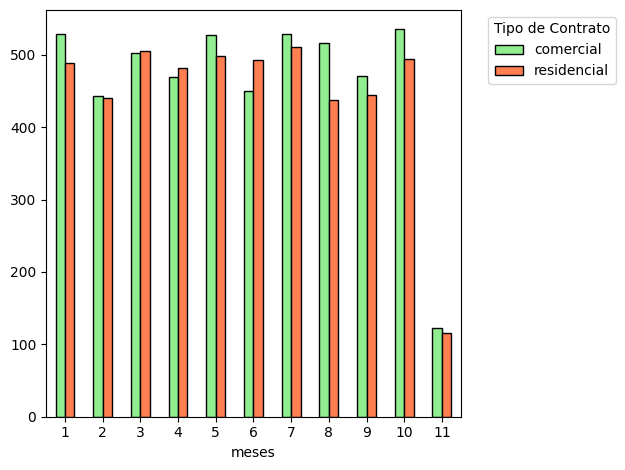

In [ ]:
df.groupby(["meses","contract_type"])["contract_type"].count().unstack(level="contract_type").plot(kind='bar', color=['lightgreen',"coral"], edgecolor='black',xlabel="meses",rot=0)
plt.legend(title="Tipo de Contrato", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 5.4. Evolución Mensual del Volumen Total de Contratos
Para cerrar las métricas de volumen, analizamos el comportamiento agregado de la cartera de clientes de Ecoenergy mes a mes. Este gráfico de barras nos permite visualizar la estabilidad de la facturación global de la empresa a lo largo de todo el ciclo anual, sin distinciones de tarifa.

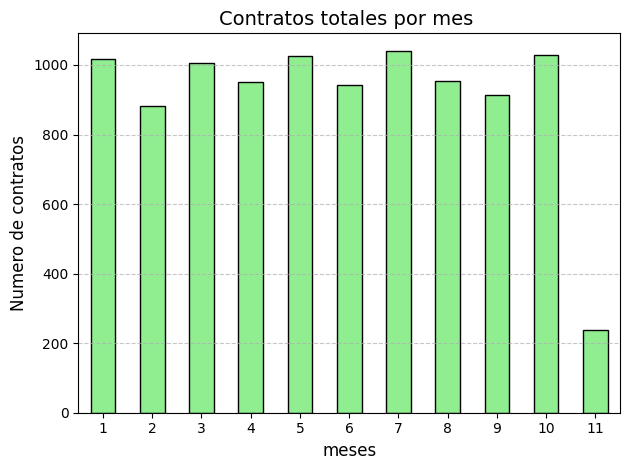

In [ ]:
df["meses"] = df["billing_date"].dt.month
df.groupby("meses")["contract_type"].count().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Contratos totales por mes ', fontsize=14)
plt.xlabel('meses', fontsize=12)
plt.ylabel('Numero de contratos', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 📝 Conclusiones Finales del Análisis Exploratorio de Datos (EDA)

Tras la ejecución de las pruebas estadísticas y la generación de las visualizaciones avanzadas, se consolidan las siguientes conclusiones estratégicas sobre la estructura operativa y financiera de Ecoenergy:

### 1. Robustez, Homogeneidad y Calidad del Dataset
* **Ausencia de Ruido y Sesgos:** El análisis mediante el método matemático del Rango Intercuartílico ($IQR$) confirmó la existencia de **0 outliers** en todas las métricas de consumo, emisiones y costes. Las distribuciones son simétricas, lo que certifica que la cartera de clientes es excepcionalmente homogénea. No existen cuentas anómalas aisladas que distorsionen los promedios generales.
* **Integridad Absoluta:** Tras el preprocesamiento, el dataset presenta un **0% de valores nulos o duplicados**, garantizando un entorno seguro para el consumo de datos desde herramientas de Business Intelligence como Google Looker Studio.

### 2. Comportamiento Financiero y Desacoplamiento Regional
* **Equilibrio Macro vs. Micro:** Al evaluar el impacto financiero por regiones, observamos que los costes totales acumulados superan los \$1.75 millones en zonas con alta concentración operativa como el Norte y el Centro. Sin embargo, el **coste medio por cliente se mantiene completamente plano (en torno a los \$900) en todas las regiones**.
* **Diagnóstico de Negocio:** Esto demuestra que las variaciones en la facturación total entre regiones se deben exclusivamente al **volumen y masa crítica de clientes en cada zona**, y no a ineficiencias tarifarias locales ni a un encarecimiento del coste por kWh en áreas específicas.

### 3. Dinámica Temporal y Factores Climáticos (Estacionalidad)
* **Homogeneidad en la Demanda:** El consumo promedio por estación se mantiene notablemente estable, rondando los **5,000 kWh** tanto en los picos térmicos (Invierno/Verano) como en las estaciones de transición (Primavera/Otoño). Esta estabilidad se replica de manera idéntica al desglosar los datos por tipo de contrato (comercial vs. residencial), manteniendo una paridad constante mes a mes.
* **Alerta de Calidad en la Captura Temporal (Mes 11):** El análisis mensual desveló una **caída drástica y artificial en el mes 11 (Noviembre)**, donde el volumen de contratos registrados se desploma a menos de 300 y el consumo agregado cae en la misma proporción. Al ser un comportamiento idéntico en ambos tipos de contratos, se concluye que no responde a un fenómeno de fuga de clientes, sino a un **cierre temprano o truncado en la captura de datos del último periodo analizado**.

### 4. Sinergia Operativa y Ambiental
* **Indexación Rígida:** La correlación de Pearson cercana a `1.00` entre el consumo energético (`consumption_kwh`) y la huella de carbono (`co2_emissions`) ratifica que las emisiones de Ecoenergy son un reflejo directo de la demanda.
* **Estrategia Futura:** Para que las políticas de sostenibilidad tengan un impacto real (rompiendo esta linealidad), es imperativo aumentar drásticamente el peso de la variable `renewable_energy_percentage` en el mix energético, priorizando la reconversión en las regiones Norte y Centro por su mayor volumen de facturación acumulada.

In [ ]:
from google.colab import files

df.to_csv("Ecoenergy.csv", index=False, encoding='utf-8')

files.download("Ecoenergy.csv")
# VALIDACIÓN FINAL

print("Valores nulos por columna:")
print(df.isna().sum())

print("\nTipos de datos:")
print(df.dtypes)

print("\nDuplicados:")
print(df.duplicated().sum())

print("\nFilas finales:")
print(len(df))

print("\nOutliers detectados:")
print(df[[
    "consumption_outlier",
    "co2_emissions_outlier",
    "cost_per_kwh_outlier",
    "total_cost_outlier",
    "renewable_energy_percentage_outlier"
]].sum())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Valores nulos por columna:
client_id                              0
client_name                            0
region                                 0
contract_type                          0
consumption_kwh                        0
billing_date                           0
co2_emissions                          0
cost_per_kwh                           0
total_cost                             0
renewable_energy_percentage            0
estacion                               0
consumption_outlier                    0
co2_emissions_outlier                  0
cost_per_kwh_outlier                   0
total_cost_outlier                     0
renewable_energy_percentage_outlier    0
meses                                  0
dtype: int64

Tipos de datos:
client_id                              string[python]
client_name                            string[python]
region                                 string[python]
contract_type                          string[python]
consumption_kwh               

Panel Interactivo de Looker Studio: Disponible para filtrar de forma dinámica por región
y contrato en el siguiente enlace:
https://datastudio.google.com/s/n1857x4DE-s
